In [1]:
import yaml
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

print(yaml.dump(cfg, sort_keys=False))

seed_everything: 2
ckpt_path: null
trainer:
  accelerator: auto
  strategy: auto
  devices: auto
  num_nodes: 1
  precision: 16-mixed
  callbacks: null
  fast_dev_run: false
  max_epochs: null
  min_epochs: null
  max_steps: 1600000
  min_steps: null
  max_time: 08:07:06:05
  limit_train_batches: null
  limit_val_batches: null
  limit_test_batches: null
  limit_predict_batches: null
  overfit_batches: 0.0
  val_check_interval: null
  check_val_every_n_epoch: 1
  num_sanity_val_steps: null
  log_every_n_steps: 29
  enable_checkpointing: true
  enable_progress_bar: false
  enable_model_summary: true
  accumulate_grad_batches: 1
  gradient_clip_val: 2
  gradient_clip_algorithm: norm
  deterministic: warn
  benchmark: null
  inference_mode: true
  use_distributed_sampler: true
  profiler: null
  detect_anomaly: false
  barebones: false
  plugins: null
  sync_batchnorm: false
  reload_dataloaders_every_n_epochs: 100
  default_root_dir: null
data:
  n_workers: 4
  batch_size: 4
  persistent_

In [2]:
from utils.data_modules import ERA5TCDataModule
import yaml

with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)
DLDA_data_loader = ERA5TCDataModule(root_dir=cfg["data"]["root_dir"],
                                    data_spatial_shape=cfg["data"]["data_spatial_shape"],
                                    r_degree_max=cfg["data"]["r_degree_max"],
                                    stat_mean_file=cfg["data"]["stat_mean_file"], 
                                    stat_std_file=cfg["data"]["stat_std_file"],
                                    combined_nc_input=True)
DLDA_data_loader.setup('.fit')
# DLDA_data_loader
dl = DLDA_data_loader.train_dataloader()

batch = next(iter(dl))
print(type(batch))
print(batch)

Combined input: True, Standardize: True, Get stat: False
Combined input: True, Standardize: True, Get stat: True
Combined input: True, Standardize: True, Get stat: True
<class 'list'>
[[tensor([[[[[-0.2291, -0.5236, -0.5857,  2.9135, -1.3033],
           [-0.2291, -0.5236, -0.5857,  2.9135, -1.3033],
           [-0.2291, -0.5236, -0.5857,  2.9135, -1.3033],
           ...,
           [-0.2291, -0.5236, -0.5857,  2.9135, -1.3033],
           [-0.2291, -0.5236, -0.5857,  2.9135, -1.3033],
           [-0.2291, -0.5236, -0.5857,  2.9135, -1.3033]],

          [[-0.2245, -0.5106, -0.6020,  2.9135, -1.3045],
           [-0.2245, -0.5093, -0.6018,  2.9135, -1.3045],
           [-0.2246, -0.5081, -0.6016,  2.9135, -1.3045],
           ...,
           [-0.2241, -0.5134, -0.6031,  2.9135, -1.3045],
           [-0.2242, -0.5125, -0.6027,  2.9135, -1.3045],
           [-0.2243, -0.5115, -0.6024,  2.9135, -1.3045]],

          [[-0.2199, -0.4976, -0.6182,  2.9135, -1.3057],
           [-0.2199, -0.

In [3]:
batch[0][0]
cfg["data"]["r_degree_max"]

10

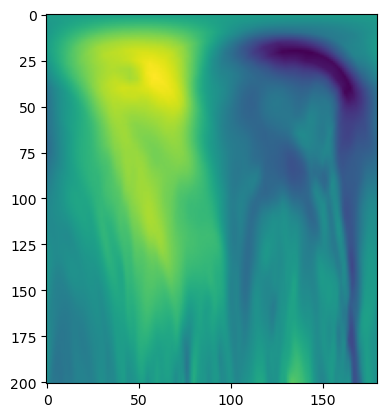

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
# obs_nc = xr.open_dataset('/wk2/yungyun/DLDA_data/ERA5_DLDA_data/labeled_and_obs_data_new/2007/200701W/200701W_2007040412_60kt_combined.nc')
# obs_nc
# plt.imshow(obs_nc.vt10.values[0,:,:])
plt.imshow(batch[0][1].numpy()[0,:,:,0])

In [11]:
import numpy as np
np.mean(batch[0][0].numpy()[:,:,:,:])

np.float32(0.1021097)

In [ ]:
import os
import numpy as np
import xarray as xr
# np.sum(batch[0][2].numpy()[0,:,:,:])
root_dir = '/wk2/yungyun/DLDA_data/ERA5_DLDA_data/labeled_and_obs_data_new/'
years = os.listdir(root_dir)
years.sort()
for year_i in ['2015']:
    TC_IDs = os.listdir(os.path.join(root_dir,year_i))
    TC_IDs.sort()
    for TC_ID in TC_IDs:
        TC_times = os.listdir(os.path.join(root_dir,year_i,TC_ID))
        TC_times.sort()
        for time_i in TC_times:
            obs_nc = xr.open_dataset(os.path.join(root_dir,year_i,TC_ID, time_i))
            if not np.isfinite(obs_nc.vt10.values).all():   # 同時抓 NaN + Inf
                print(f'{TC_ID}/{time_i}')
                print(obs_nc.time.values)
            if not np.isfinite(obs_nc.vr10.values).all():   # 同時抓 NaN + Inf
                print(f'{TC_ID}/{time_i}')
                print(obs_nc.time.values)
            obs_nc.close()            
        print(f'finish {TC_ID}')
    print(f'finish {year_i}')

finish 201501W
finish 201502W
finish 201503W
finish 201504W
finish 201505W
finish 201506W
finish 201507W
finish 201508W
finish 201509W
finish 201510W
finish 201511W
finish 201512W
finish 201513W
finish 201514W
finish 201515W
finish 201516W
finish 201517W
finish 201518W
finish 201519W
finish 201520W
finish 201521W
finish 201522W
finish 201523W
finish 201524W
finish 201525W
finish 201526W
finish 201527W
finish 201528W
finish 201529W
finish 2015


In [ ]:
np.mean(obs_nc.vt10.values)

np.float64(nan)

In [ ]:
## create obs stat mean and std files
import xarray as xr
import numpy as np
ds = xr.open_dataset("/wk2/yungyun/code_space/DLDA/DLDA_code/utils/stat_mean.nc")
ds['vt10'] = (('time', 'latitude', 'longitude'),np.ones([1,1,1])*4.328362624359293)
ds['vr10'] = (('time', 'latitude', 'longitude'),np.ones([1,1,1])*2.0824332612434047)
ds.to_netcdf("/wk2/yungyun/code_space/DLDA/DLDA_code/utils/obs_stat_mean.nc")

ds = xr.open_dataset("/wk2/yungyun/code_space/DLDA/DLDA_code/utils/stat_std.nc")
ds['vt10'] = (('time', 'latitude', 'longitude'),np.ones([1,1,1])*3.9954967715383978)
ds['vr10'] = (('time', 'latitude', 'longitude'),np.ones([1,1,1])*3.9124839044998443)
ds.to_netcdf("/wk2/yungyun/code_space/DLDA/DLDA_code/utils/obs_stat_std.nc")

In [ ]:
from glob import glob
## total_cases
root_dir = '/wk2/yungyun/DLDA_data/ERA5_DLDA_data'
labeled_dir = 'labeled_and_obs_data'
obs_dir = 'labeled_and_obs_data'
background_dir =  ['sstfillc_ERA5_TC_plus_lead06hr','sstfillc_ERA5_TC_plus_lead12hr','sstfillc_ERA5_TC_plus_lead24hr','sstfillc_ERA5_TC_plus_lead48hr']
background_cases=[]
labeled_cases=[]
obs_cases=[]
for lead_dir in background_dir:
    for y in range(2007,2016):
        background_cases += sorted(glob(f'{root_dir}/{lead_dir}/{y}/*'))
        labeled_cases += sorted(glob(f'{root_dir}/{labeled_dir}/{y}/*'))
        obs_cases += sorted(glob(f'{root_dir}/{obs_dir}/{y}/*'))
# case_combined_files = [sorted(glob(f'{c}/{name_pattern}')) for c in cases]
# self.file0_list_combined = [file for a_case in case_combined_files for file in a_case[:-1]]
# self.file1_list_combined = [file for a_case in case_combined_files for file in a_case[1:]]

In [ ]:
root_dir = '/wk2/yungyun/DLDA_data/ERA5_DLDA_data/sstfillc_ERA5_TC_plus_lead06hr'
cases = sorted(glob(f'{root_dir}/{2007}/*'))
for y in range(2007+1,2016):
    cases += sorted(glob(f'{root_dir}/{y}/*'))
name_pattern = '*combined.nc'
case_combined_files = [sorted(glob(f'{c}/{name_pattern}')) for c in cases]
file0_list_combined = [file for a_case in case_combined_files for file in a_case[:-1]]
len(file0_list_combined)

8550

In [ ]:
file0_list_combined.replace('a','b')

AttributeError: 'list' object has no attribute 'replace'

In [ ]:
name_pattern = '*combined.nc'
case_combined_files = [sorted(glob(f'{c}/{name_pattern}')) for c in background_cases]
file0_list_combined = [file for a_case in case_combined_files for file in a_case]
case_combined_filesnew_paths = file0_list_combined.copy()
for replace_dir in background_dir:
    case_combined_filesnew_paths = [p.replace(replace_dir, labeled_dir) for p in case_combined_filesnew_paths]
len(case_combined_filesnew_paths)
# len(file0_list_combined)
# file0_list_combined[0]
case_combined_filesnew_paths[1] 

'/wk2/yungyun/DLDA_data/ERA5_DLDA_data/labeled_and_obs_data/2007/200701W/200701W_2007033109_28kt_combined.nc'

In [ ]:
file0_list_combined[0].replace(replace_dir, labeled_dir)


'/wk2/yungyun/DLDA_data/ERA5_DLDA_data/sstfillc_ERA5_TC_plus_lead06hr/2007/200701W/200701W_2007033106_25kt_combined.nc'

In [ ]:
import xarray as xr
ds = xr.open_dataset("/wk2/yungyun/code_space/DLDA/DLDA_code/utils/stat_mean.nc")
ds

<xarray.Dataset> Size: 1kB
Dimensions:      (time: 1, level: 13, latitude: 1, longitude: 1)
Coordinates:
  * time         (time) datetime64[ns] 8B 2013-12-03
  * level        (level) int32 52B 50 100 150 200 250 ... 600 700 850 925 1000
  * latitude     (latitude) float64 8B 0.0
  * longitude    (longitude) float64 8B 0.0
Data variables: (12/31)
    u            (time, level, latitude, longitude) float64 104B ...
    v            (time, level, latitude, longitude) float64 104B ...
    t            (time, level, latitude, longitude) float64 104B ...
    q            (time, level, latitude, longitude) float64 104B ...
    z            (time, level, latitude, longitude) float64 104B ...
    w            (time, level, latitude, longitude) float64 104B ...
    ...           ...
    hgt          (time, latitude, longitude) float64 8B ...
    landmask     (time, latitude, longitude) float64 8B ...
    diurnal_sin  (time, latitude, longitude) float64 8B ...
    diurnal_cos  (time, latitude, longitude) float64 8B ...
    doy_sin      (time, latitude, longitude) float64 8B ...
    doy_cos      (time, latitude, longitude) float64 8B ...
Attributes:
    CDI:                       Climate Data Interface version 2.1.1 (https://...
    Conventions:               CF-1.6
    history:                   Thu Mar 27 00:21:06 2025: cdo -O -s -P 32 -b F...
    cdo_openmp_thread_number:  32
    CDO:                       Climate Data Operators version 2.1.1 (https://...

In [ ]:
len(case_combined_files),len(case_combined_filesnew_paths)
len(case_combined_filesnew_paths[1])
len(case_combined_files[0])
# case_combined_files[1]


41